# Assignment 4

In [1]:
import pandas as pd
import numpy as np
import librosa
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datasets import load_dataset, Audio, concatenate_datasets
import IPython.display as ipd
from collections import Counter

DATA = Path("data")
LJSPEECH = DATA / "LJSpeech-1.1"
PONY = DATA / "pony-speech"
LLM = DATA / "llm"
IMG = Path("img")

if not IMG.exists():
  IMG.mkdir()


In [2]:
%%bash

./src/load_data.sh


Dataset already exists: ./data/LJSpeech-1.1


## EDA and Metric Analysis

In [3]:
data = pd.read_csv(LJSPEECH / "metadata.csv", sep="|", header=None, names=["file", "text", "normalized_text"])
data


,file,text,normalized_text
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...
...,...,...,...
13095,LJ050-0274,made certain recommendations which it believes...,made certain recommendations which it believes...
13096,LJ050-0275,materially improve upon the procedures in effe...,materially improve upon the procedures in effe...
13097,LJ050-0276,"As has been pointed out, the Commission has no...","As has been pointed out, the Commission has no..."
13098,LJ050-0277,with the active cooperation of the responsible...,with the active cooperation of the responsible...


### Statistics

From the README:

| Metric | Value |
| --- | --- |
| Total Clips | 13,100 |
| Total Words | 225,715 |
| Total Characters | 1,308,674 |
| Total Duration | 23:55:17 |
| Mean Clip Duration | 6.57 sec |
| Min Clip Duration | 1.11 sec |
| Max Clip Duration | 10.10 sec |
| Mean Words per Clip | 17.23 |
| Distinct Words | 13,821 |

### Abbreviations

Some words are abbreviated in the transcript:

| Abbreviation | Expansion |
| --- | --- |
| Mr. | Mister |
| Mrs. | Misess (*) |
| Dr. | Doctor |
| No. | Number |
| St. | Saint |
| Co. | Company |
| Jr. | Junior |
| Maj. | Major |
| Gen. | General |
| Drs. | Doctors |
| Rev. | Reverend |
| Lt. | Lieutenant |
| Hon. | Honorable |
| Sgt. | Sergeant |
| Capt. | Captain |
| Esq. | Esquire |
| Ltd. | Limited |
| Col. | Colonel |
| Ft. | Fort |

* there's no standard expansion of "Mrs."

In [4]:
SR = 22050

paths = []
for f in data["file"]:
  path = LJSPEECH / f"wavs/{f}.wav"
  paths.append(str(path))
  _, sr = librosa.load(path, sr=None)

  if SR is None:
    SR = sr
  elif SR != sr:
    print(f"File {f} has a different sample rate: {sr} != {SR}")

data['path'] = paths
SR


22050

In [5]:
data


,file,text,normalized_text,path
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...",data/LJSpeech-1.1/wavs/LJ001-0001.wav
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,data/LJSpeech-1.1/wavs/LJ001-0002.wav
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,data/LJSpeech-1.1/wavs/LJ001-0003.wav
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed...",data/LJSpeech-1.1/wavs/LJ001-0004.wav
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,data/LJSpeech-1.1/wavs/LJ001-0005.wav
...,...,...,...,...
13095,LJ050-0274,made certain recommendations which it believes...,made certain recommendations which it believes...,data/LJSpeech-1.1/wavs/LJ050-0274.wav
13096,LJ050-0275,materially improve upon the procedures in effe...,materially improve upon the procedures in effe...,data/LJSpeech-1.1/wavs/LJ050-0275.wav
13097,LJ050-0276,"As has been pointed out, the Commission has no...","As has been pointed out, the Commission has no...",data/LJSpeech-1.1/wavs/LJ050-0276.wav
13098,LJ050-0277,with the active cooperation of the responsible...,with the active cooperation of the responsible...,data/LJSpeech-1.1/wavs/LJ050-0277.wav


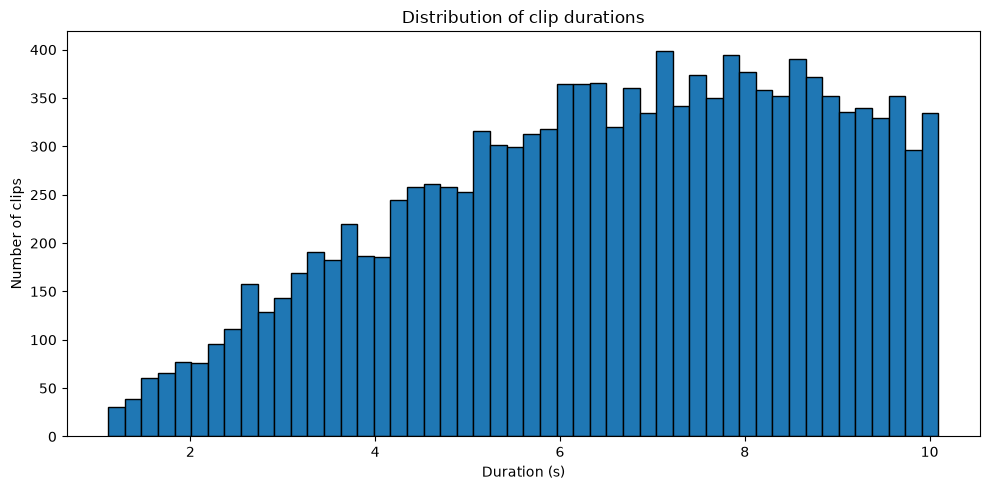

In [6]:
d = [librosa.get_duration(path=p) for p in data['path']]

fig = plt.figure(figsize=(10, 5))
plt.hist(d, bins=50, edgecolor='black')
plt.xlabel('Duration (s)')
plt.ylabel('Number of clips')
plt.title('Distribution of clip durations')
plt.tight_layout()
plt.show()
fig.savefig("img/clip_duration.png", dpi=300)


Mean words per sample: 16.8993893129771


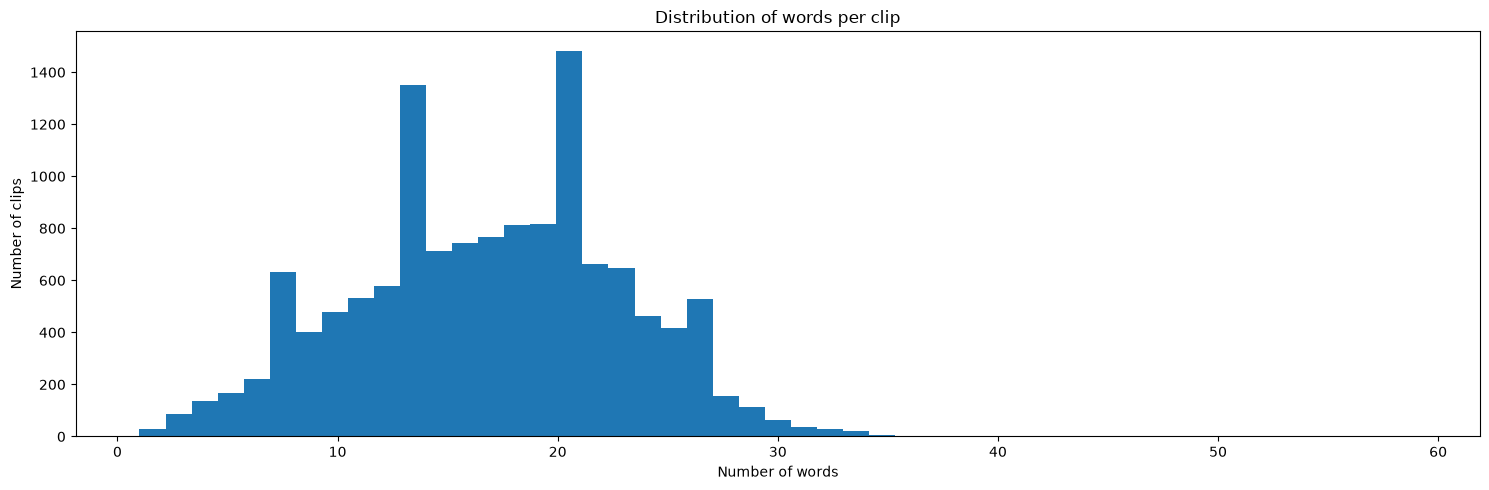

In [7]:
words = np.array([len(t.split()) for t in data['text']])
print("Mean words per sample:", words.mean())
bins = np.linspace(words.min(), words.max(), 50)

fig = plt.figure(figsize=(15, 5))

plt.hist(words, bins=bins, linewidth=3)
plt.xlabel('Number of words')
plt.ylabel('Number of clips')
plt.title('Distribution of words per clip')

fig.tight_layout()
fig.savefig("img/clip_words.png", dpi=300)


In [8]:
train, test = train_test_split(data, train_size=0.9, random_state=42)
train, val = train_test_split(train, train_size=0.9, random_state=42)

train.to_parquet(LJSPEECH / "train.parquet")
test.to_parquet(LJSPEECH / "test.parquet")
val.to_parquet(LJSPEECH / "val.parquet")


### Pony Speech Dataset

In [9]:
ponyds = load_dataset("synthbot/pony-speech", cache_dir=PONY)


Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

In [10]:
s = ponyds['train'][0]

audio = s['audio'].get_all_samples()
display(s)
ipd.Audio(audio.data.numpy(), rate=audio.sample_rate)


{'speaker': 'Rainbow Dash',
 'gender': 'female',
 'source': 'eqg:legend of everfree',
 'start': 4364.40824,
 'end': 4365.77424,
 'style': 'Neutral',
 'noise': '',
 'transcription': "I've lost track.",
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x796683482390>,
 'duration': 1.3659999999999854}

Total number of speakers: 227


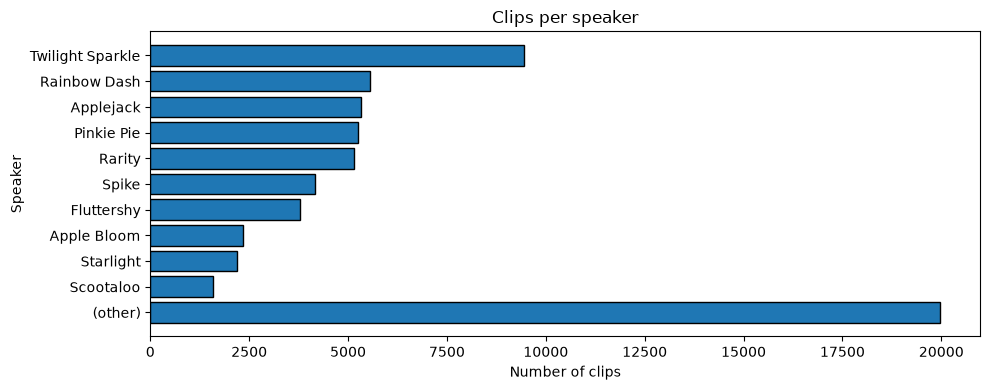

In [11]:
counts = Counter(ponyds['train']['speaker'])
speakers, values = zip(*counts.most_common())

print(f"Total number of speakers: {len(speakers)}")

TOP = 10
top = counts.most_common(TOP)
rest = sum(v for _, v in counts.most_common()[TOP:])
labels = [s for s, _ in top] + ['(other)']
vals   = [v for _, v in top] + [rest]

plt.figure(figsize=(10, max(4, len(labels) * 0.2)))
plt.barh(labels, vals, edgecolor='black')
plt.gca().invert_yaxis()
plt.xlabel('Number of clips')
plt.ylabel('Speaker')
plt.title('Clips per speaker')
plt.tight_layout()
plt.savefig(IMG / "mlp_speakers.png", dpi=300)
plt.show()


In [12]:
speakers = set([t[0] for t in top])

top_pony_ds = ponyds['train'].filter(
    lambda s, n: s in speakers and n == "",
    input_columns=['speaker', 'noise'],
)

top_pony_ds


Filter:   0%|          | 0/64783 [00:00<?, ? examples/s]

Dataset({
    features: ['speaker', 'gender', 'source', 'start', 'end', 'style', 'noise', 'transcription', 'audio', 'duration'],
    num_rows: 20821
})

Mean words per sample: 7.428125450266558


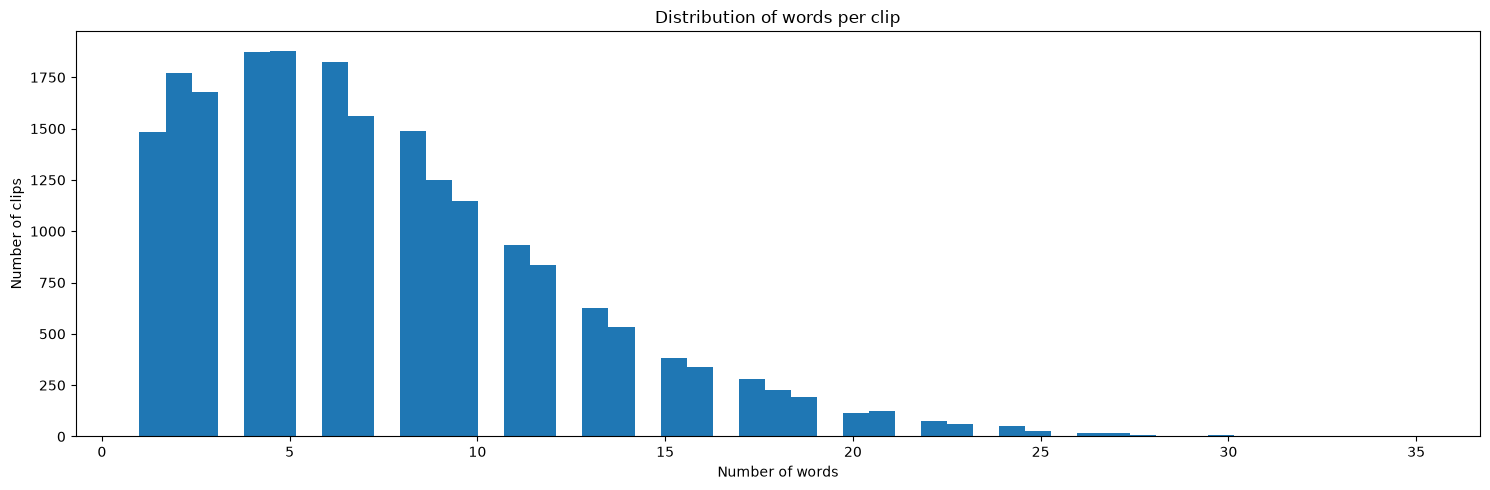

In [13]:
words = np.array([len(t.split()) for t in top_pony_ds['transcription']])
print("Mean words per sample:", words.mean())
bins = np.linspace(words.min(), words.max(), 50)

fig = plt.figure(figsize=(15, 5))

plt.hist(words, bins=bins, linewidth=3)
plt.xlabel('Number of words')
plt.ylabel('Number of clips')
plt.title('Distribution of words per clip')

fig.tight_layout()
fig.savefig("img/mlp_clip_words.png", dpi=300)


In [14]:
twilight_sparkle_ds = ponyds['train'].filter(
    lambda s, n: s == "Twilight Sparkle" and n == "",
    input_columns=['speaker', 'noise'],
)

twilight_sparkle_ds


Dataset({
    features: ['speaker', 'gender', 'source', 'start', 'end', 'style', 'noise', 'transcription', 'audio', 'duration'],
    num_rows: 4549
})

In [15]:
rainbow_dash_ds = ponyds['train'].filter(
    lambda s, n: s == "Rainbow Dash" and n == "",
    input_columns=['speaker', 'noise'],
)

rainbow_dash_ds


Dataset({
    features: ['speaker', 'gender', 'source', 'start', 'end', 'style', 'noise', 'transcription', 'audio', 'duration'],
    num_rows: 2243
})

In [16]:
applejack_ds = ponyds['train'].filter(
    lambda s, n: s == "Applejack" and n == "",
    input_columns=['speaker', 'noise'],
)

applejack_ds


Dataset({
    features: ['speaker', 'gender', 'source', 'start', 'end', 'style', 'noise', 'transcription', 'audio', 'duration'],
    num_rows: 3031
})

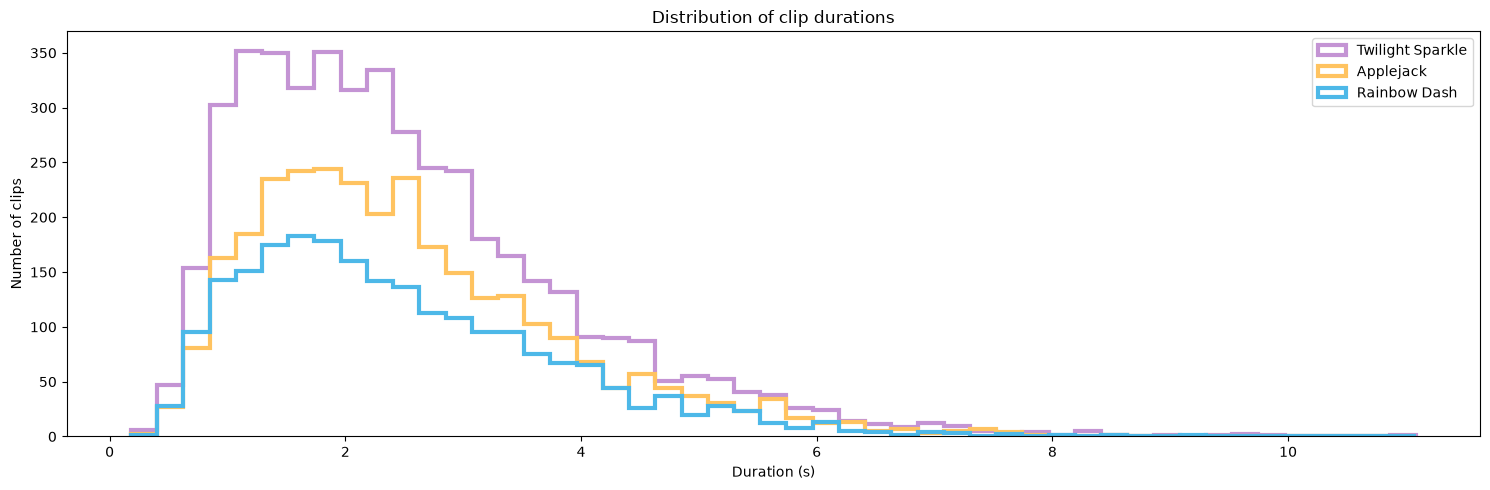

In [17]:
durations = {
    "Twilight Sparkle": twilight_sparkle_ds['duration'],
    "Applejack":        applejack_ds['duration'],
    "Rainbow Dash":     rainbow_dash_ds['duration'],
}

colors = {
  "Twilight Sparkle": "#C494D4",
  "Applejack": "#FFC360",
  "Rainbow Dash": "#4DB8E8"
}

all_d = np.concatenate([np.asarray(v) for v in durations.values()])
bins = np.linspace(all_d.min(), all_d.max(), 50)

fig = plt.figure(figsize=(15, 5))

for label, d in durations.items():
  plt.hist(d, bins=bins, histtype='step', linewidth=3, label=label, color=colors[label])

plt.xlabel('Duration (s)')
plt.ylabel('Number of clips')
plt.title('Distribution of clip durations')
plt.legend()

fig.tight_layout()
fig.savefig("img/mlp_clip_duration.png", dpi=300)


In [18]:
top_pony_ds.cast_column("audio", Audio(sampling_rate=SR))
top_pony_ds.to_parquet(PONY / "top_pony.parquet")

# twilight_sparkle_ds = twilight_sparkle_ds.cast_column("audio", Audio(sampling_rate=SR))
# twilight_sparkle_ds.to_parquet(PONY / "twilight_sparkle.parquet")

# applejack_ds = applejack_ds.cast_column("audio", Audio(sampling_rate=SR))
# applejack_ds.to_parquet(PONY / "applejack.parquet")

# rainbow_dash_ds = rainbow_dash_ds.cast_column("audio", Audio(sampling_rate=SR))
# rainbow_dash_ds.to_parquet(PONY / "rainbow_dash.parquet")


Creating parquet from Arrow format:   0%|          | 0/49 [00:00<?, ?ba/s]

4497398640

In [19]:
SEED = 42
CAP = 4000
speakers = {s: i for i, s in enumerate(speakers)}

def prep(name, spk_id):
  ds = top_pony_ds.filter(lambda s: s == name, input_columns=['speaker'])
  ds = ds.shuffle(seed=SEED)
  if len(ds) > CAP:
    ds = ds.select(range(CAP))
  ds = ds.add_column('speaker_id', [spk_id] * len(ds))
  tmp = ds.train_test_split(test_size=0.2, seed=SEED)
  vt = tmp['test'].train_test_split(test_size=0.5, seed=SEED)
  return tmp['train'], vt['train'], vt['test']

parts = [prep(name, sid) for name, sid in speakers.items()]
splits = {
  'train':      concatenate_datasets([p[0] for p in parts]).shuffle(seed=SEED),
  'validation': concatenate_datasets([p[1] for p in parts]),
  'test':       concatenate_datasets([p[2] for p in parts]),
}

for name, ds in splits.items():
  ds = ds.cast_column('audio', Audio(sampling_rate=SR))
  ds.to_parquet(PONY / f'pony_{name}.parquet')
  print(f'{name:>11}: {len(ds):>5} clips')


Filter:   0%|          | 0/20821 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1103 [00:00<?, ? examples/s]

Filter:   0%|          | 0/20821 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/3031 [00:00<?, ? examples/s]

Filter:   0%|          | 0/20821 [00:00<?, ? examples/s]

...

      train: 16214 clips


Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

 validation:  2026 clips


Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

       test:  2032 clips


### LLM Generated

In [20]:
EDGE_CASES = {
  # ------------------------------------------------------------------
  # NUMBERS — cardinals vs ordinals vs years vs identifiers. The same
  # digits must be verbalized differently by context: "1984" is a year,
  # "1,984" is a quantity, "Room 101" is spelled digit-by-digit-ish.
  # ------------------------------------------------------------------
  "numbers": [
    "The year 1984 saw 1,984 attendees, not 19.84 percent of them.",
    "She finished 1st, he came in 22nd, and I was 103rd.",
    "Chapter 7, verse 21, on page 356.",
    "It costs $19.99, was $1,299.00, and is now -$5 off.",
  ],

  # ------------------------------------------------------------------
  # DATES & TIMES — many surface forms for the same underlying value.
  # ------------------------------------------------------------------
  "dates_times": [
    "On 03/04/2025 we met at 9:00 AM sharp.",
    "The 21st of March, 2024, around noon-ish.",
    "See you at 12:00 PM — no, make it 12 midnight.",
    "From 1914–1918 and again in '39.",
    "It's 5 o'clock somewhere, roughly 17:00 UTC.",
    "Q3 FY2026 begins Jul 1st.",
  ],

  # ------------------------------------------------------------------
  # AMBIGUOUS ABBREVIATIONS — the hard ones. "St." is Saint OR Street,
  # "Dr." is Doctor OR Drive, "No." is Number OR the word "no", "in." is
  # inch OR the word "in". Context alone disambiguates. Mirrors the
  # expansion table you started this dataset work with.
  # ------------------------------------------------------------------
  "abbrev_ambiguous": [
    "Dr. Vance lives at 12 Elm Dr., not on St. Mary's St.",
    "See No. 5 on the list; I said no, not number nine.",
    "The board is 6 in. wide, in. case you wondered.",
  ],

  # ------------------------------------------------------------------
  # ACRONYMS vs INITIALISMS — NASA/NATO are read as words; FBI/USA/HTML
  # are spelled letter-by-letter. Mixed ones (JPEG, SQL) split opinion.
  # ------------------------------------------------------------------
  "acronyms": [
    "NASA and the FBI disagreed about the UFO.",
    "Send the HTML, CSS, and JSON to the API via HTTP.",
    "She works at UNESCO but studied at MIT and UCLA.",
    "Convert the JPEG to PNG, then query the SQL DB.",
    "The CEO, CFO, and CTO all use PGP and 2FA.",
    "RADAR, LASER, and SCUBA were once acronyms too.",
  ],

  # ------------------------------------------------------------------
  # HETERONYMS — same spelling, different pronunciation by context.
  # Several sentences use the word TWICE with both pronunciations, which
  # is the single most revealing test of a pronunciation model.
  # ------------------------------------------------------------------
  "heteronyms": [
    "I read a book yesterday, and I read every single day.",
    "The bandage was wound around the wound.",
    "They were too close to the door to close it.",
    "The buck does funny things when the does are near.",
    "He could lead if he would get the lead out.",
  ],

  # ------------------------------------------------------------------
  # SYMBOLS & MATH — must be spoken, not skipped. &, %, @, +, =, /, °, ^.
  # ------------------------------------------------------------------
  "symbols_math": [
    "Profit rose 40% while costs fell ~15%.",
    "R&D spent $2M @ a 3.5x return.",
    "Solve for x: 3x + 7 = 22, so x = 5.",
    "Water is H2O; carbon dioxide is CO2.",
    "It's 25°C outside, or 77°F if you prefer.",
    "The ratio is 16:9 and the odds are 2/1.",
    "Press Ctrl+Alt+Del, then #4 on the menu.",
    "5 > 3, 2 < 10, and 4 ≠ 5.",
  ],

  # ------------------------------------------------------------------
  # URLS / EMAILS / HANDLES — punctuation-dense, verbalization varies.
  # ------------------------------------------------------------------
  "web_handles": [
    "Email me at first.last@example.co.uk today.",
    "Visit https://www.site.org/path?id=42&ref=x now.",
    "Follow @user_name and tag #TTS2026 in the post.",
    "The file is C:\\Users\\test\\audio_01.wav locally.",
    "Ping me on the #general channel, not @here.",
  ],

  # ------------------------------------------------------------------
  # CAPITALIZATION & EMPHASIS — ALL CAPS often implies loudness/emphasis;
  # single letters may be spelled; mIxEd case is a normalizer trap.
  # ------------------------------------------------------------------
  "caps_emphasis": [
    "I said STOP right NOW, do you understand?",
    "The word 'the' vs THE difference in emphasis.",
    "iPhone, eBay, and macOS keep their odd casing.",
    "WOW that was AMAZING, absolutely INCREDIBLE.",
    "Spell it out: C-A-T spells cat.",
  ],

  # ------------------------------------------------------------------
  # PUNCTUATION & PROSODY — pauses, questions, exclamations, asides,
  # trailing-off, interruptions. Tests phrasing and intonation.
  # ------------------------------------------------------------------
  "prosody": [
    "Wait... what? You're leaving — now — really?",
    "Well, you see, the thing is, um, I forgot.",
    "\"Don't,\" she whispered, \"say a word.\"",
    "First: gather data. Second: clean it. Third: train.",
    "Is it done? Yes! No... maybe. I'm not sure.",
    "He paused (for effect) before the big reveal.",
    "So. Much. Drama. Every. Single. Time.",
  ],

  # ------------------------------------------------------------------
  # FOREIGN WORDS & DIACRITICS — loanwords and names with accents.
  # ------------------------------------------------------------------
  "foreign_diacritics": [
    "We ate crème brûlée at a café in Zürich.",
    "The jalapeño piñata was a naïve idea.",
    "Beyoncé and Björk performed a déjà-vu duet.",
    "Order the pho, gnocchi, and a croissant.",
    "Herr Müller met Señor García in São Paulo.",
  ],

  # ------------------------------------------------------------------
  # CONTRACTIONS & POSSESSIVES — apostrophe-heavy, stacked contractions.
  # ------------------------------------------------------------------
  "contractions": [
    "Y'all'd've known if you'd've asked earlier.",
    "It's the cat's toy, not the dogs' bones.",
    "Rock 'n' roll ain't dead, don't ya know.",
    "The '90s were the boss's favorite decade.",
    "Who's whose? Whose is who's? It's confusing.",
  ],

  # ------------------------------------------------------------------
  # DISFLUENCIES & INTERJECTIONS — filler, laughter, hesitation. Common
  # in conversational corpora (and in your pony-speech transcripts).
  # ------------------------------------------------------------------
  "disfluencies": [
    "Uh, hmm, well... I guess, maybe, sort of?",
    "Haha, no way — hahaha — you're kidding me!",
    "Oooh, aaah, ummm, let me think about it.",
    "Ugh. Meh. Pfft. Whatever, honestly.",
    "Shh! Psst — over here — shhhh, be quiet.",
  ],

  # ------------------------------------------------------------------
  # LONG & NESTED — breath planning, long-range prosody, deep clauses.
  # ------------------------------------------------------------------
  "long_nested": [
    "The report, which had been drafted by the committee "
    "that was formed after the incident that occurred last "
    "spring, when nobody was paying attention, was finally, "
    "after several delays and no small amount of confusion, "
    "released to the public on a rainy Tuesday afternoon.",
    "If you go, and if she stays, and if the weather holds, "
    "and if nothing else goes wrong, then, and only then, "
    "will we finally, at long last, be able to leave.",
  ],

  # ------------------------------------------------------------------
  # SHORT & SINGLE-TOKEN — minimal context, one-word/one-letter inputs.
  # ------------------------------------------------------------------
  "short_single": [
    "Yes.",
    "No!",
    "A.",
    "Hmm?",
    "Go.",
    "1",
    "OK",
  ],

  # ------------------------------------------------------------------
  # EXPRESSIVE REPETITION — stretched letters and repeated punctuation
  # that imply prosody (length, excitement). Common in casual transcripts.
  # ------------------------------------------------------------------
  "expressive": [
    "Nooooo, that's soooo unfair!!!",
    "Wheeee!!! Again, again, again!!!",
    "Whyyyy would you do thaaat???",
    "Yesss!!! We did it!!! Finally!!!",
  ],

  # ------------------------------------------------------------------
  # MIXED LANGUAGE / CODE-SWITCHING — one utterance, two scripts/langs.
  # Especially relevant given your Ukrainian + English work.
  # ------------------------------------------------------------------
  "code_switch": [
    "She said «привіт» and then switched to English.",
    "The word Schadenfreude has no clean translation.",
    "Ordering déjà vu sushi feels très bizarre.",
    "Він сказав 'okay' і пішов далі.",
  ],

  # ------------------------------------------------------------------
  # DEGENERATE / EMPTY — robustness. A good system must not CRASH here;
  # it should emit silence or a graceful fallback. These catch the bugs
  # that take a service down in production, not the ones that sound off.
  # ------------------------------------------------------------------
  "degenerate": [
    "",                       # empty string
    " ",                      # single space
    "   \t\n  ",              # whitespace only
    ".",                      # single punctuation
    "!?!?!?",                 # punctuation only
    "...",                    # ellipsis only
    "😀🎉🐴",                  # emoji only
    "\u200b\u200b",           # zero-width spaces (invisible)
    "aaaaaaaaaaaaaaaaaaaa",   # long single token, no vowboth boundary
    "🐴 pony 🐴 pony 🐴",       # text interleaved with emoji
  ],
}

if not LLM.exists():
  LLM.mkdir()

rows = [(text, category) for category, samples in EDGE_CASES.items() for text in samples]
df = pd.DataFrame(rows, columns=['text', 'category'])
df.to_parquet(LLM / "llm_edge_cases.parquet", index=False)
